# POPANE Emotion Analysis

This notebook demonstrates data loading, EDA, PCA, and ML classification.

In [1]:
import dataclasses
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import duckdb
import importlib
#################################
from select import select
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import (StandardScaler,
                                   LabelEncoder)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd
import warnings
from sklearn.preprocessing import LabelEncoder

############################################

from emotion import POPANE
from emotion.models.random_forest import EmotionRandomForest
import emotion.preprocessing.analysis
importlib.reload(emotion.preprocessing.analysis)
from emotion.preprocessing.analysis import (generate_emotion_presence_matrix,
                                            generate_heatmap,
                                            generate_study_size_bar_chart)
from emotion.utils import get_size
from emotion.dataloader.popaneloader import POPANEDataLoader

warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

output_dir = Path('../figures')
output_dir.mkdir(exist_ok=True)
print('Libraries imported!')

Libraries imported!


In [2]:
popane = POPANE()
db_path = '../data/processed/propane_emotion.db'
conn = duckdb.connect(database=db_path, read_only=True)

# Limit memory and threads
conn.execute("SET memory_limit='512MB'")
conn.execute("SET threads=2")
tables = conn.execute('SHOW TABLES').fetchall()
print(f'Tables: {[t[0] for t in tables]}')

Tables: ['study1', 'study2', 'study3', 'study4', 'study5', 'study6', 'study7']


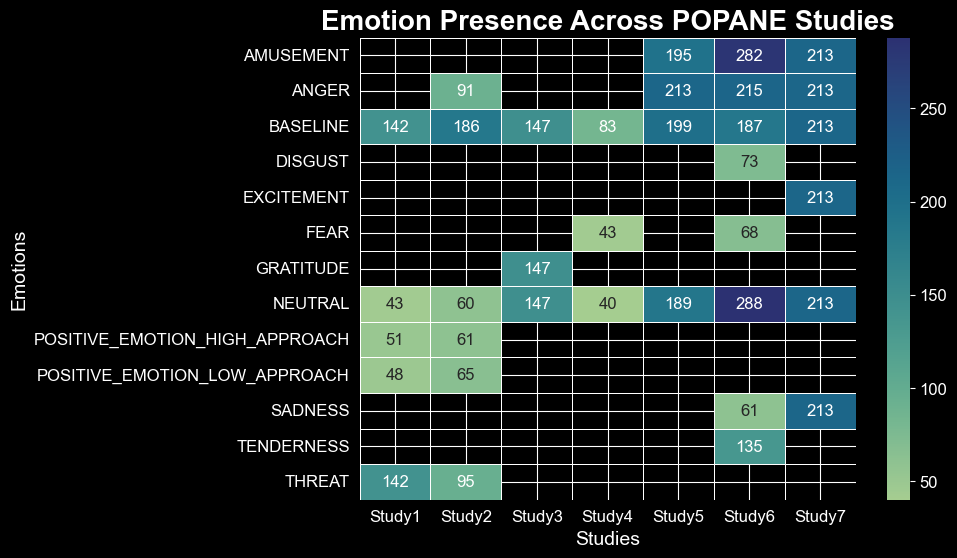

In [3]:
all_emotions = popane.get_unique_emotions_for_all_studies()
# print(f'Unique emotions: {len(all_emotions)}')

loader = POPANEDataLoader()
emotion_matrix = generate_emotion_presence_matrix(all_emotions, loader)

# plt.figure(figsize=(14, 8))
f = generate_heatmap(emotion_matrix)

In [8]:
get_size("../data/raw")

../data/raw
['study1', 'study2', 'study3', 'study4', 'study5', 'study6', 'study7']
study1
study2
study3
study4
study5
study6
study7


{'study1': {'Size': 9.083087725564837, 'File_Count': 568},
 'study2': {'Size': 14.571958892978728, 'File_Count': 744},
 'study3': {'Size': 24.6743556112051, 'File_Count': 588},
 'study4': {'Size': 6.734359834343195, 'File_Count': 249},
 'study5': {'Size': 18.528295166790485, 'File_Count': 995},
 'study6': {'Size': 31.71857468597591, 'File_Count': 1496},
 'study7': {'Size': 50.40543109178543, 'File_Count': 1491}}

../data/raw
['study1', 'study2', 'study3', 'study4', 'study5', 'study6', 'study7']
study1
study2
study3
study4
study5
study6
study7


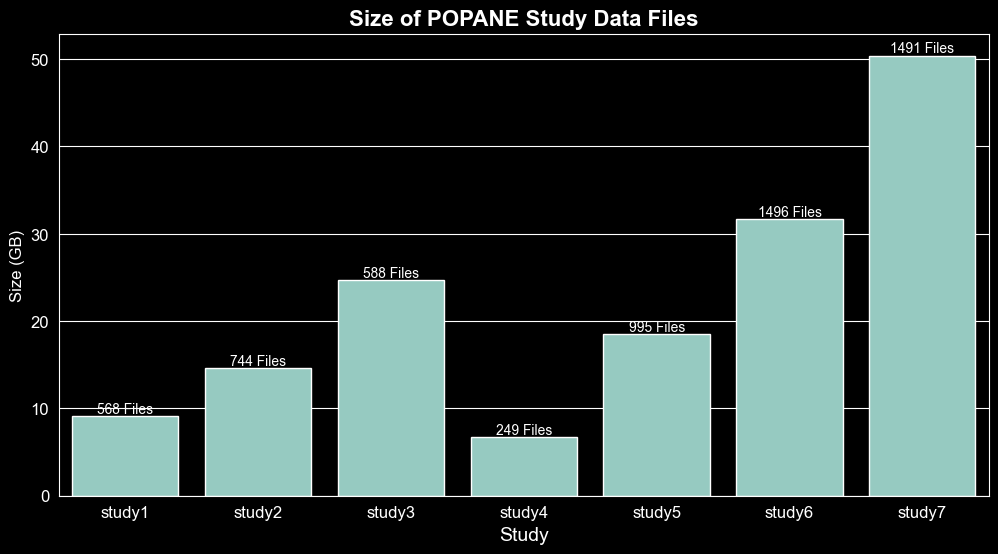

In [9]:
generate_study_size_bar_chart(POPANEDataLoader("../data/raw"))

In [10]:
# Get data from study5
query = '''
        SELECT * FROM study1
        WHERE SUBJECT_ID < 5
        '''
df_study1 = conn.execute(query).fetchdf()


In [11]:
sampled_dfs = []
for affect_val in df_study1['marker'].unique():
    subset = df_study1[df_study1['marker'] == affect_val]
    n_samples = min(2000, len(subset))  # Smaller sample
    sampled_dfs.append(subset.sample(n=n_samples, random_state=42))

df_study1 = pd.concat(sampled_dfs, ignore_index=True)
print(f'Loaded {len(df_study1)} samples')
print(f'Unique marker: {df_study1["marker"].nunique()}')
print(f'Marker distribution:\n{df_study1["marker"].value_counts()}')

Loaded 8000 samples
Unique marker: 4
Marker distribution:
marker
-1      2000
 309    2000
 209    2000
 108    2000
Name: count, dtype: int64


In [12]:
df_study1.columns

Index(['Subject_ID', 'timestamp', 'affect', 'ECG', 'EDA', 'temp',
       'respiration', 'SBP', 'DBP', 'marker'],
      dtype='object')

In [13]:
print('Statistics:')
print(df_study1.describe())
print(f'\nEmotion distribution:')
print(df_study1['marker'].value_counts())

Statistics:
        Subject_ID    timestamp       affect          ECG          EDA  \
count  8000.000000  8000.000000  8000.000000  8000.000000  8000.000000   
mean      2.490000   517.630268     6.586113     0.058908     5.577016   
std       1.121186   129.259785     2.718269     0.309995     6.526888   
min       1.000000   148.511000     0.000000    -0.861000    -0.320000   
25%       1.000000   460.068500     3.600000    -0.071000     0.970000   
50%       2.000000   529.021500     7.500000    -0.001000     1.980000   
75%       4.000000   615.320750     8.600000     0.085000    14.045000   
max       4.000000   725.936000     9.900000     2.410000    20.120000   

              temp  respiration          SBP          DBP       marker  
count  8000.000000  8000.000000  8000.000000  8000.000000  8000.000000  
mean     33.325634     0.287785    87.270821    97.698121   156.250000  
std       1.519434     1.040480    26.634217    24.239362   115.301124  
min      28.800000    -5.2900

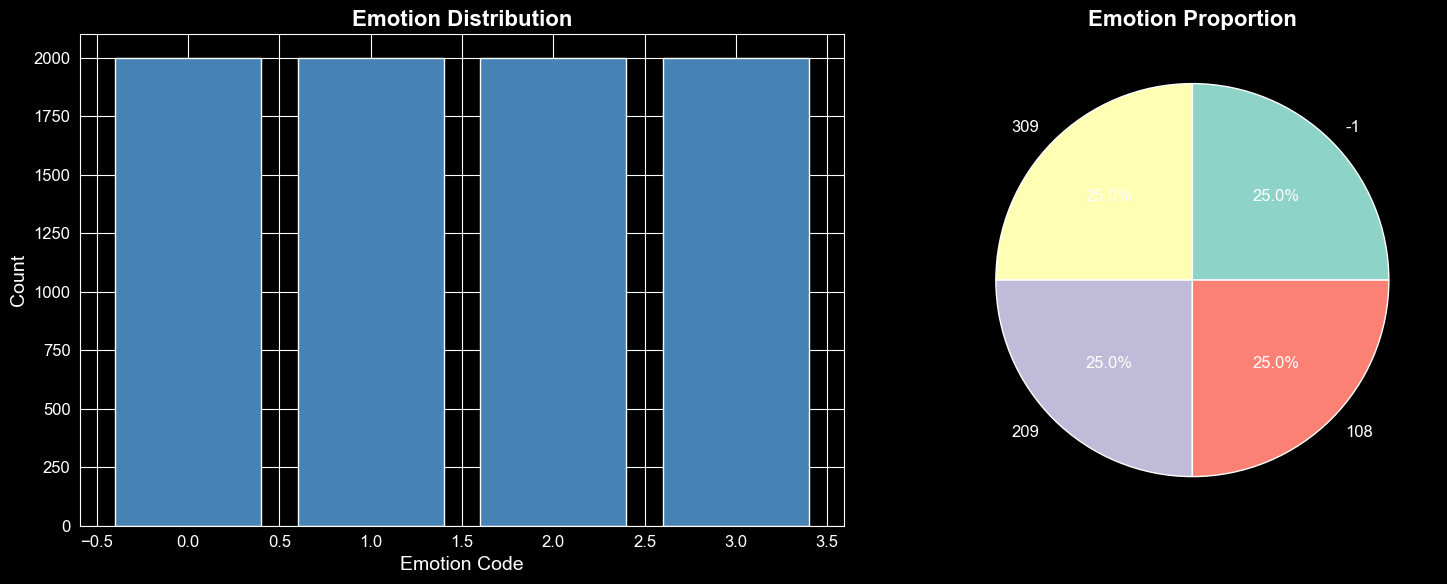

Saved: emotion_distribution.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
emotion_counts = df_study1['marker'].value_counts()
axes[0].bar(range(len(emotion_counts)), emotion_counts.values, color='steelblue')
axes[0].set_xlabel('Emotion Code')
axes[0].set_ylabel('Count')
axes[0].set_title('Emotion Distribution')
axes[1].pie(emotion_counts.values, labels=emotion_counts.index, autopct='%1.1f%%')
axes[1].set_title('Emotion Proportion')
plt.tight_layout()
plt.savefig(output_dir / 'emotion_distribution.png', dpi=300)
plt.show()
print('Saved: emotion_distribution.png')

In [15]:
df_study1.rename({"Subject_ID": "study_id"}, inplace=True)

In [16]:
from emotion.visualization.figure import POPANEFigureGenerator
query = '''
        SELECT Subject_ID, timestamp, affect, ECG, EDA, SBP,  DBP, temp , respiration,  marker as STIMULI
        FROM study1
        WHERE Subject_ID < 10 and SUBJECT_ID
        '''
df_study1 = conn.execute(query).fetchdf()
df_study1 = df_study1.merge(POPANE().get_stimuli_meta(), how='inner', on=["STIMULI"])

In [17]:
POPANE().get_stimuli_meta().head()

,STIMULI,STIMULI NAME,STIMULI TYPE,STIMULI VALENCE,STIMULI SHORTNAMEFILE,USED IN STUDY,TIME INTERVAL IN SECONDS,STIMULI SOURCE - REFERENCES
0,-1,Physiobaseline,resting baseline,Neutral,Baseline,"1,2,3,4,5,6,7",300 (except of Study 3 = 180),NaN
1,101,Emperor 1,film,Neutral,Neutral1,"5,6",120,45
2,102,Twin Peaks: Fire Walk with Me,film,Neutral,Neutral2,6,120,36
3,103,Emperor 2,film,Neutral,Neutral3,6,120,42
4,104,Blue 2,film,Neutral,Neutral4,6,120,22


In [18]:
df_study1.rename(columns={'Subject_ID': 'SUBJECT_ID', "STIMULI SHORTNAMEFILE":"EMOTION"}, inplace=True)
df_study1["STUDY_NAME"] = "STUDY1"

Baseline Baseline
Baseline Neutral8
Baseline Threat


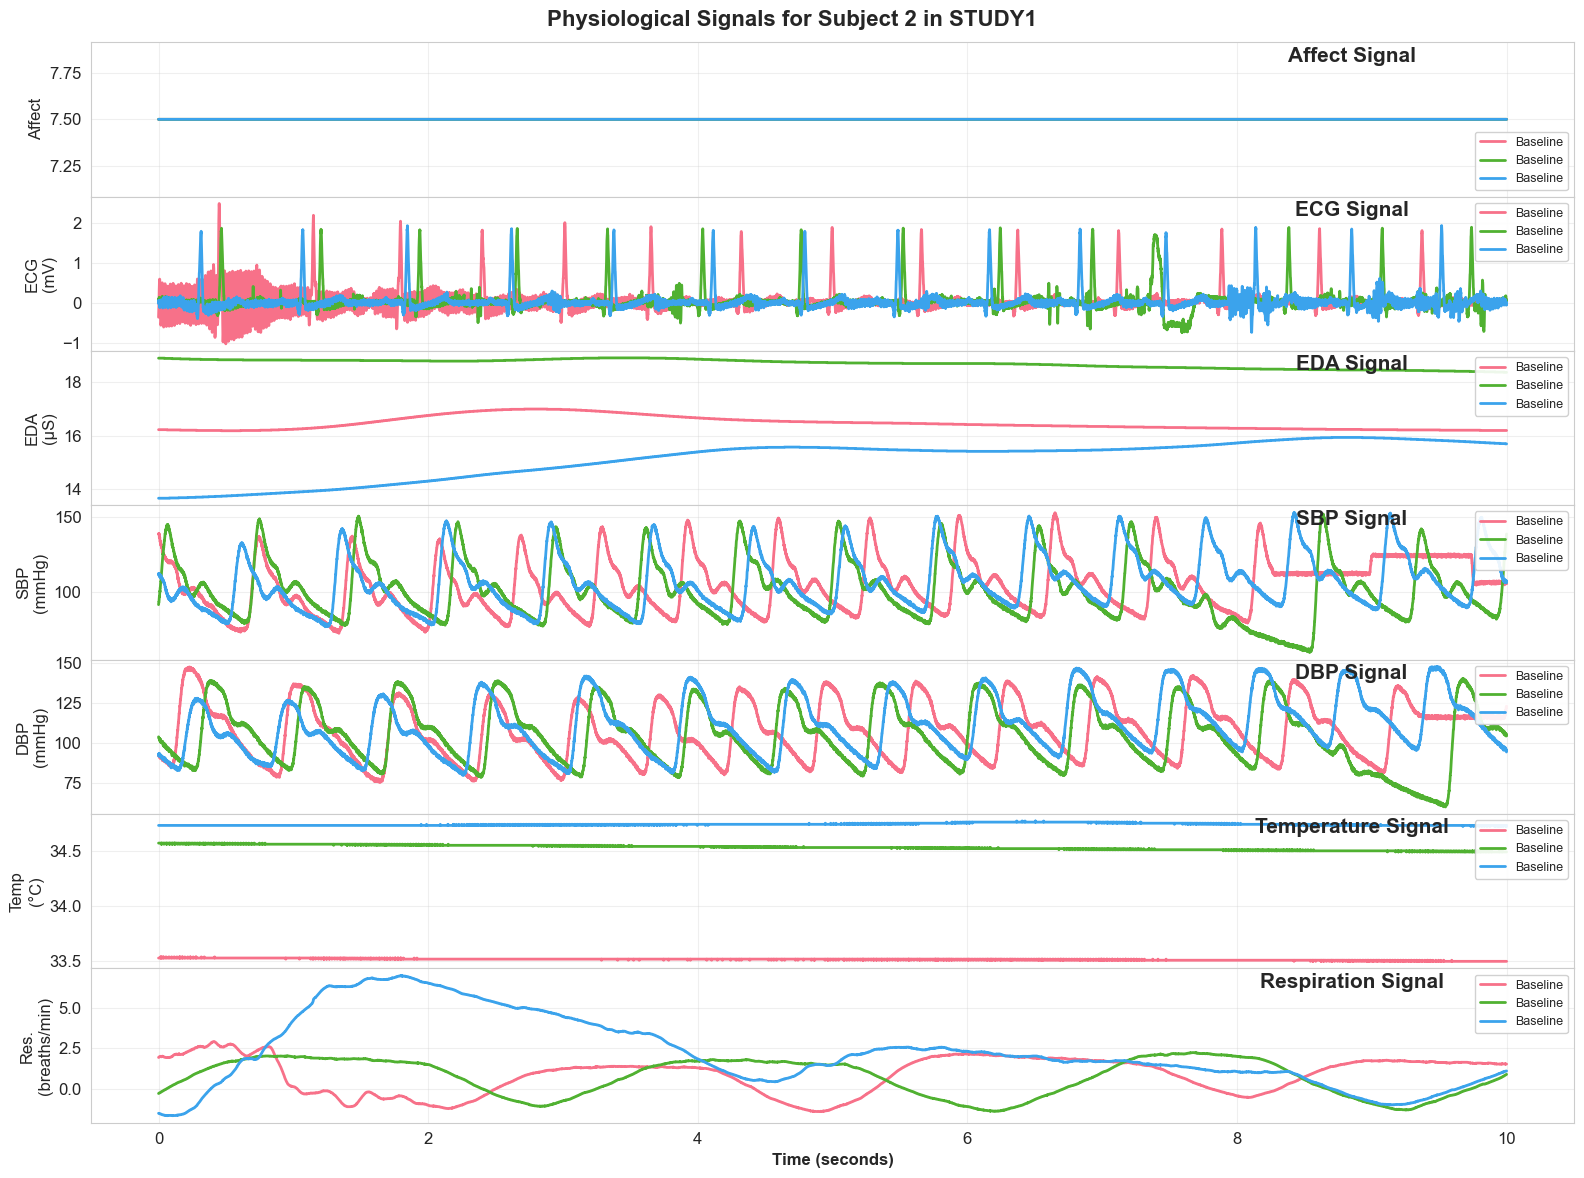

In [19]:
f= POPANEFigureGenerator.create_figure_for_subject(df_study1, 2, start_end=(0,10))

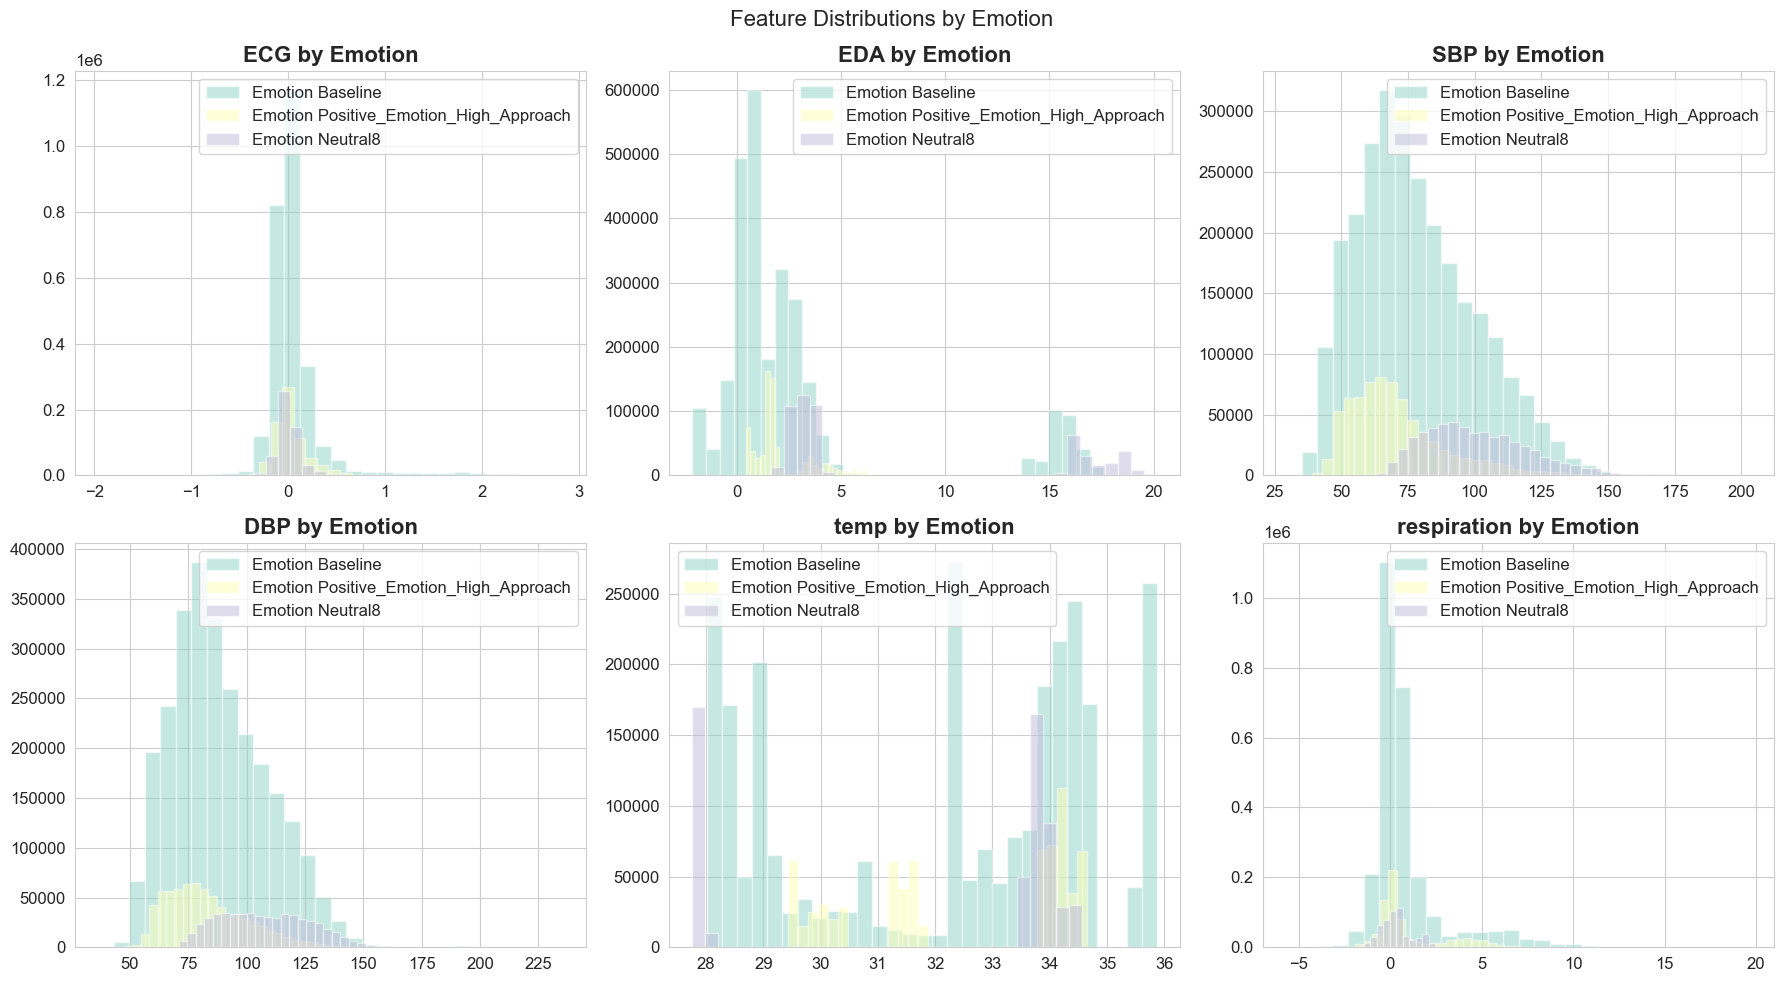

Saved: feature_distributions_by_emotion.png


In [20]:
top_emotions = df_study1['EMOTION'].value_counts().head(3).index.tolist()
df_sub = df_study1[df_study1['EMOTION'].isin(top_emotions)]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, feat in enumerate(['ECG', 'EDA', 'SBP', 'DBP', 'temp', 'respiration']):
    ax = axes.flatten()[idx]
    if feat in df_sub.columns:
        for emo in top_emotions:
            data = df_sub[df_sub['EMOTION'] == emo][feat].dropna()
            ax.hist(data, alpha=0.5, bins=30, label=f'Emotion {emo}')
        ax.set_title(f'{feat} by Emotion')
        ax.legend()
plt.suptitle('Feature Distributions by Emotion', fontsize=16)
plt.tight_layout()
plt.savefig(output_dir / 'feature_distributions_by_emotion.png', dpi=300)
plt.show()
print('Saved: feature_distributions_by_emotion.png')

In [21]:
X = df_study1[['ECG', 'EDA', 'SBP', 'DBP', 'temp', 'respiration']].dropna()
y = df_study1.loc[X.index, 'EMOTION']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
print(f'Features: {X.shape[1]}')
print(f'Explained variance (first 5): {pca.explained_variance_ratio_[:5]}')

Features: 6
Explained variance (first 5): [0.29402874 0.20811588 0.16742796 0.15372378 0.09921697]


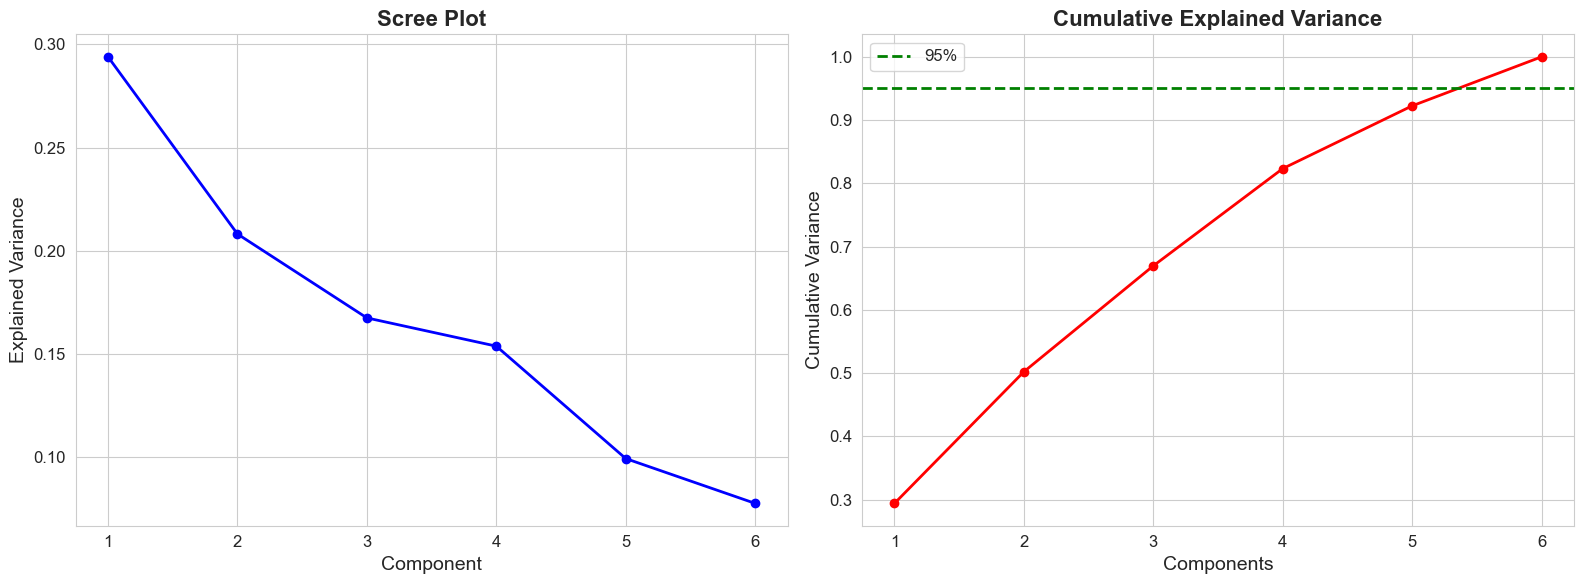

Components for 95% variance: 6
Saved: pca_explained_variance.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, 'bo-')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Explained Variance')
axes[0].set_title('Scree Plot')
cumsum = np.cumsum(pca.explained_variance_ratio_)
axes[1].plot(range(1, len(cumsum) + 1), cumsum, 'ro-')
axes[1].axhline(y=0.95, color='g', linestyle='--', label='95%')
axes[1].set_xlabel('Components')
axes[1].set_ylabel('Cumulative Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
plt.tight_layout()
plt.savefig(output_dir / 'pca_explained_variance.png', dpi=300)
plt.show()
n_comp_95 = np.argmax(cumsum >= 0.95) + 1
print(f'Components for 95% variance: {n_comp_95}')
print('Saved: pca_explained_variance.png')

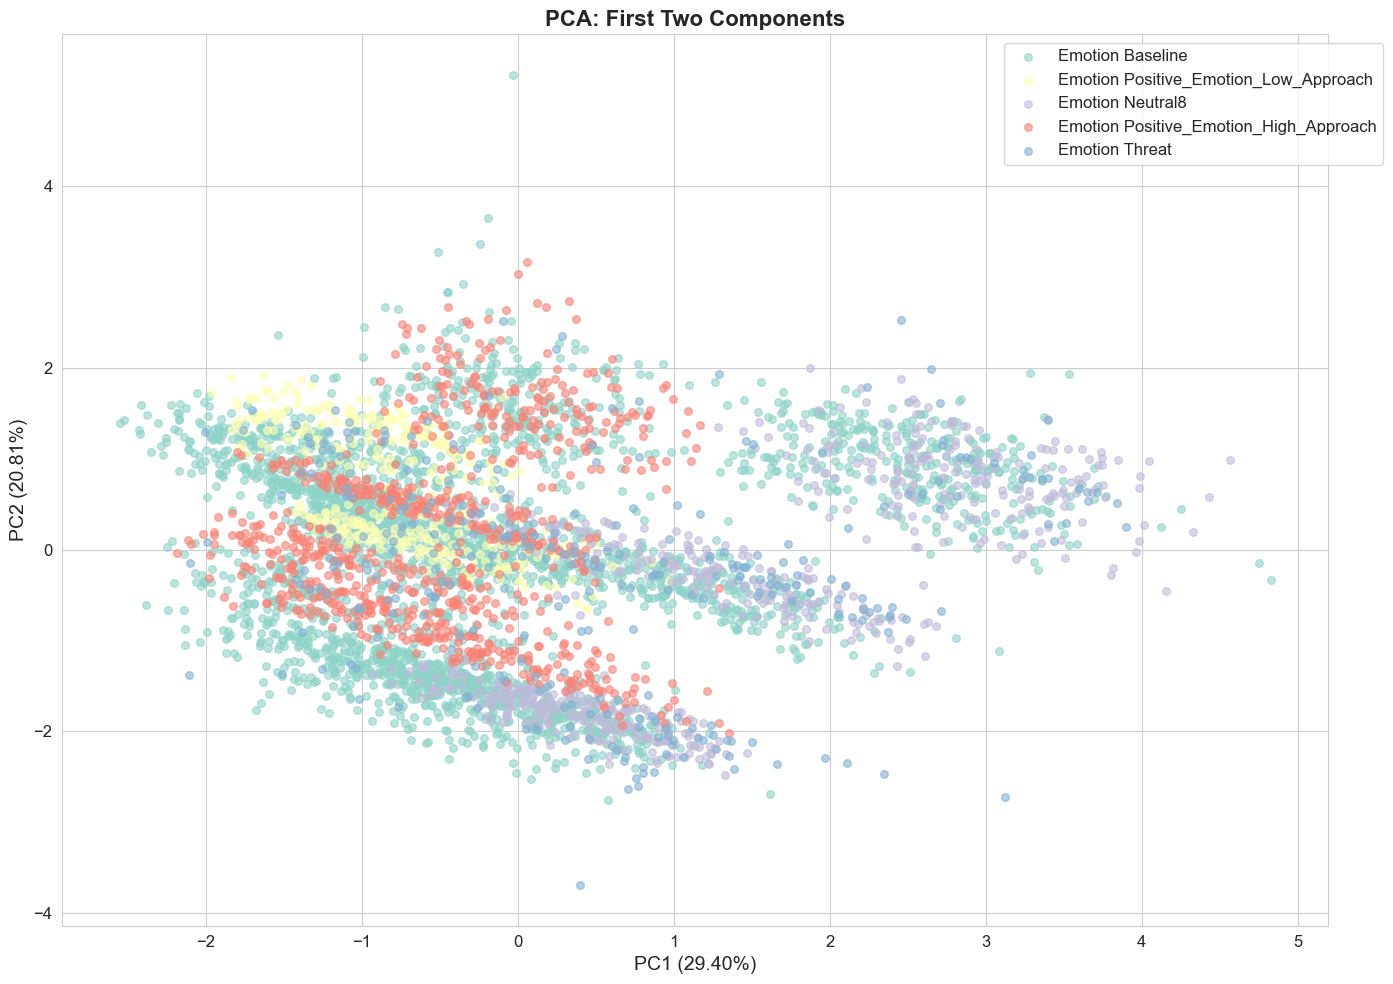

Saved: pca_2d_visualization.png


In [23]:
plt.figure(figsize=(14, 10))
sample_idx = np.random.choice(len(X_pca), min(5000, len(X_pca)), replace=False)
X_sample = X_pca[sample_idx]
y_sample = y.iloc[sample_idx]
for emo in y_sample.unique():
    mask = y_sample == emo
    plt.scatter(X_sample[mask, 0], X_sample[mask, 1], alpha=0.6, s=30, label=f'Emotion {emo}')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.title('PCA: First Two Components')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig(output_dir / 'pca_2d_visualization.png', dpi=300)
plt.show()
print('Saved: pca_2d_visualization.png')

In [24]:
X_ml = df_study1[['ECG', 'EDA', 'SBP', 'DBP', 'temp', 'respiration']].dropna()
y_ml = df_study1.loc[X_ml.index, 'EMOTION']
le = LabelEncoder()

y_ml = le.fit_transform(y_ml)

print(f'Dataset: {X_ml.shape}')
print(y_ml.shape)
X_train, X_test, y_train, y_test = train_test_split(X_ml, y_ml, test_size=0.2, random_state=42, stratify=y_ml)
print(f'Train: {len(X_train)}, Test: {len(X_test)}')

Dataset: (4588636, 6)
(4588636,)
Train: 3670908, Test: 917728


In [25]:
print('Training Random Forest...')
rf_model = RandomForestClassifier(
    n_estimators=30,
    max_depth=20,
    min_samples_leaf=50,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)
print(f'Train Accuracy: {train_acc:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

Training Random Forest...
Train Accuracy: 0.9988
Test Accuracy: 0.9987


In [26]:
print('Classification Report:')
print(classification_report(y_test, y_pred_test))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    538794
           1       1.00      1.00      1.00    108000
           2       1.00      1.00      1.00    144000
           3       1.00      1.00      1.00     72000
           4       1.00      0.99      1.00     54934

    accuracy                           1.00    917728
   macro avg       1.00      1.00      1.00    917728
weighted avg       1.00      1.00      1.00    917728



In [27]:
le.classes_

array(['Baseline', 'Neutral8', 'Positive_Emotion_High_Approach',
       'Positive_Emotion_Low_Approach', 'Threat'], dtype=object)

In [28]:
cm = confusion_matrix(y_test, y_pred_test, labels=le.classes_)

TypeError: '<' not supported between instances of 'str' and 'int'

In [ ]:
# Access feature_importances_ from the underlying model
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12, 8))
plt.bar(range(len(importances)), importances[indices], color='steelblue')
plt.xticks(range(len(importances)), [['ECG', 'EDA', 'SBP', 'DBP', 'temp', 'respiration'][i] for i in indices], rotation=45, ha='right')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance', fontsize=16)
plt.tight_layout()
plt.savefig(output_dir / 'feature_importance.png', dpi=300)
plt.show()
print('Saved: feature_importance.png')
print('\nTop features:')
for i in range(len(indices)):
    print(f'  {['ECG', 'EDA', 'SBP', 'DBP', 'temp', 'respiration'][indices[i]]}: {importances[indices[i]]:.4f}')

In [ ]:
conn.close()
print('='*50)
print('Analysis Complete!')
print('='*50)
print(f'\nTrain Accuracy: {train_acc:.2%}')
print(f'Test Accuracy: {test_acc:.2%}')
print(f'\nFigures saved:')
for f in sorted(output_dir.glob('*.png')):
    print(f'  - {f.name}')
print(f'\nComponents for 95%: {n_comp_95}')
print(f'Top feature: {['ECG', 'EDA', 'SBP', 'DBP', 'temp', 'respiration'][indices[0]]}')